# Imports and File Path Setup

In [1]:
import numpy as np
import pandas as pd
from scipy.io import loadmat
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
import sys
import zarr
import napari 
import dask.array as da
import math 

import dask.array as da 
from tifffile import imwrite


In [2]:
# Change this variable to where your python packages are. Don't remove the r
package_dir = r'C:\Users\Kenny\LLSM-CME-ANALYSIS\Final\src'

# Change this variable to the directory where all your data is. Don't remove the r
base_dir = r'\\10.158.28.194\ActiveNAS\Kenny'
#base_dir = r'C:\Users\Kenny\akamatsu'
# Change this variable to the current data you are analyzing in your base_dir.
input_file_directory = 'lumenoid_2_analysis/'

In [3]:
# Visualizing the detections in Napari
pythonPackagePath = os.path.abspath(package_dir)
sys.path.append(pythonPackagePath)
from intensity_time_plots import filter_track_ids_by_length_ranges, random_track_ids
from intensity_time_plots import intensity_time_plot, createBufferForLifetimeCohort
from intensity_time_plots import createBufferForLifetimeCohort_normalized, cumulative_plots, cumulative_plots_ax
# from parallel import Detector
from gaussian_visualization import visualize_3D_gaussians
filtered_tracks_treatment = pd.read_pickle(os.path.join(base_dir, input_file_directory, 'datasets', 'region_filtered_tracks_final.pkl'))

## AP2 Histogram Lifetimes

In [4]:
###### Set the following variables #######


# Background intensity for each channel

# background_channel_1 = 240
# background_channel_2 = 150
# background_channel_3 = 170

# # framerate (in milliseconds)

# framerate_msec = 2200

# protein names (optional)

channel1_name = 'Arp2/3-Halo'
channel2_name = 'Dynamin2-tagGFP2'
channel3_name = 'AP2-tagRFPt'

In [5]:
value_to_plot = 'voxel_sum_adjusted'
# value_to_plot = 'voxel_sum'
# value_to_plot = 'peak_mean'
# value_to_plot = 'peak_max'

if value_to_plot == 'voxel_sum_adjusted':
    background_channel_1 = 0
    background_channel_2 = 0
    background_channel_3 = 0

# use this list to see all possible values to plot
# track_df.columns

In [6]:
# filtered_tracks_control
# label1 = 'Control'
# label2 = 'Tracks Filtered'

label1 = 'Apical'
label2 = 'Lateral'
label3 = 'Basal'

In [7]:
# range of track lengths to plot in each cohort, in frames
custom_length_ranges = [[5, 10], [11,15], [16, 20], [21, 25], [26, 30], [31, 40], [41,90]]

In [8]:
def trackFilter(region_to_plot, plot_all_channels, tracks, channels_to_plot = [True, True]):
    """
    Filter out tracks with intensity peaks occurring too early relative to the start frame.

    Parameters:
    1. region_to_plot (str): Region to filter tracks by. If 'All', no filtering is applied. Otherwise should be 'Apical', 'Lateral', or 'Basal'.
    2. plot_all_channels (bool): If True, all channels are considered. If False, only postive tracks are considered.
    3. tracks (pd.Dataframe): DataFrame containing track information, including 'membrane_region', 'channel1_positive', and 'channel2_positive'.

    Outputs:
    1. pd.DataFrame: Filtered DataFrame containing tracks with the specified region and channel conditions.
    """
        

    if region_to_plot == 'All':
        #filtered_tracks_all_control = filtered_tracks_control.copy()
        filtered_tracks_all_treatment = tracks.copy()

    if region_to_plot != 'All':
        # filtered_tracks_all_control = filtered_tracks_control.copy()
        filtered_tracks_all_treatment = tracks.copy()
        # filtered_tracks_all_control = filtered_tracks_all_control[filtered_tracks_all_control['membrane_region'] == region_to_plot]
        filtered_tracks_all_treatment = filtered_tracks_all_treatment[filtered_tracks_all_treatment['membrane_region'] == region_to_plot]

    #channels_to_plot = [True, True]
    if plot_all_channels:
    # tracks_channel_subset_control = filtered_tracks_all_control.copy()
        tracks_channel_subset_treatment = filtered_tracks_all_treatment.copy()
        return tracks_channel_subset_treatment
    else:
        tracks_channel_subset_treatment = filtered_tracks_all_treatment[(tracks['channel1_positive'] == channels_to_plot[0]) & (filtered_tracks_all_treatment['channel2_positive'] == channels_to_plot[1])]
        return tracks_channel_subset_treatment

In [9]:
# Plot histogram of all track lengths (lifetimes)
def createHistogramAP2Lifetimes(tracks,framerate_msec, plot_all_channels, bins = np.linspace(0, 300, 51)):
    if plot_all_channels:
        # For using the tracks_channel_subset 
        #n, bins, patches = plt.hist(all_lifetimes, bins=50, facecolor='#2ab0ff', edgecolor='#e0e0e0', linewidth=0.5, alpha=0.7)

        # For using the raw membrane region filtered tracks
        n, bins, patches = plt.hist(tracks['track_length']*framerate_msec/1000, bins=bins, facecolor='#2ab0ff', edgecolor='#e0e0e0', linewidth=0.5, alpha=0.7)

        n = n.astype('int')

        # Good old loop. Choose colormap of your taste
        for i in range(len(patches)):
            patches[i].set_facecolor(plt.cm.viridis(n[i]/max(n)))

        #plt.hist(all_lifetimes, bins=50, edgecolor=black)
        plt.xlabel('Time (s)')  # X-axis label
        plt.ylabel('Frequency')  # Y-axis label
        plt.title('Track lengths (lifetimes)')  # Title of the histogram
        plt.show()
    else:
        tracks_apical = tracks[tracks['membrane_region'] == 'Apical']
        tracks_lateral = tracks[tracks['membrane_region'] == 'Lateral']
        tracks_basal = tracks[tracks['membrane_region'] == 'Basal']
        # 'all lifetimes' is a variable of all the track lengths, multipilied by time per track
        #all_lifetimes_control =  tracks_channel_subset_control['track_length']*framerate_msec/1000
        #all_lifetimes_treatment =  tracks_channel_subset_treatment['track_length']*framerate_msec/1000
        all_lifetimes_apical = tracks_apical['track_length']*framerate_msec/1000
        all_lifetimes_lateral = tracks_lateral['track_length']*framerate_msec/1000
        all_lifetimes_basal = tracks_basal['track_length']*framerate_msec/1000
        plt.hist(all_lifetimes_apical, bins=bins, color = 'red', edgecolor='black', alpha=0.35, density=True, label=label1)
        plt.hist(all_lifetimes_lateral, bins=bins, color = 'blue', edgecolor='black', alpha=0.35, density=True, label=label2)
        plt.hist(all_lifetimes_basal, bins=bins, color = 'green', edgecolor='black', alpha=0.35, density=True, label=label3)
        plt.xlabel('AP2 lifetime (s)', fontsize = 12, weight = 'bold')  # X-axis label
        plt.ylabel('Frequency Density', fontsize = 12, weight = 'bold')  # Y-axis label
        plt.title(f'AP2 lifetimes in Membrane Regions', fontsize = 14, weight = 'bold')  # Title of the histogram
        plt.legend(prop = {'weight':'bold'})
        plt.show()

## Box and Whisker plots of AP2 lifetimes in Membrane Regions

In [10]:
def createBoxWhiskerPlot(tracks, region_to_plot,framerate_msec):
    if region_to_plot:
        all_lifetimes = tracks['track_length']*framerate_msec/1000
        plt.boxplot(all_lifetimes, labels=['Lumenoid 2'])
        plt.ylabel('AP2 lifetime (s)', fontsize = 12, weight = 'bold')  # X-axis label
        plt.title('Boxplot of AP2 lifetimes in Lumenoid', fontsize = 14, weight = 'bold')
        plt.show()
    else:
        tracks_apical = tracks[tracks['membrane_region'] == 'Apical']
        tracks_lateral = tracks[tracks['membrane_region'] == 'Lateral']
        tracks_basal = tracks[tracks['membrane_region'] == 'Basal']

        # 'all lifetimes' is a variable of all the track lengths, multipilied by time per track
        #all_lifetimes_control =  tracks_channel_subset_control['track_length']*framerate_msec/1000
        #all_lifetimes_treatment =  tracks_channel_subset_treatment['track_length']*framerate_msec/1000
        all_lifetimes_apical = tracks_apical['track_length']*framerate_msec/1000
        all_lifetimes_lateral = tracks_lateral['track_length']*framerate_msec/1000
        all_lifetimes_basal = tracks_basal['track_length']*framerate_msec/1000
        
        plt.boxplot([all_lifetimes_apical, all_lifetimes_lateral, all_lifetimes_basal],labels=[label1, label2, label3])
        plt.ylabel('AP2 lifetime (s)', fontsize = 12, weight = 'bold')
        plt.title(f'AP2 lifetimes in Membrane Regions', fontsize = 14, weight = 'bold')
        plt.show()

In [11]:
def compareLumenoidsBoxPlot(lumenoid1, lumenoid2, region_to_plot, lumenoid1_name, lumenoid2_name, lumenoid1_frame_ms, lumenoid2_frame_ms,channels_to_plot=[]):
    """
    Filter out tracks with intensity peaks occurring too early relative to the start frame.

    Parameters:
    1. lumenoid1 (pd.Dataframe): Name of the first lumenoid to filter tracks.
    2. lumenoid2 (pd.Dataframe): Name of the second lumenoid to filter tracks.
    3. region_to_plot (str): The region to filter tracks by. If 'All', no filtering is applied. Otherwise should be 'Apical', 'Lateral', or 'Basal'.
    4. lumenoid1_name (str): Name of the first lumenoid for labeling.
    5. lumenoid2_name (str): Name of the second lumenoid for labeling.
    Outputs:
    1. pd.DataFrame: Filtered DataFrame containing tracks with the specified region and channel conditions.

    """

    if region_to_plot == 'All':
        lumenoid1_all_lifetimes = lumenoid1['track_length']*lumenoid1_frame_ms/1000
        lumenoid2_all_lifetimes = lumenoid2['track_length']*lumenoid2_frame_ms/1000
        
        # lumenoid1_all_lifetimes = lumenoid1_all_lifetimes[lumenoid1_all_lifetimes <= 300]
        # lumenoid2_all_lifetimes = lumenoid2_all_lifetimes[lumenoid2_all_lifetimes <= 300]
        plt.boxplot([lumenoid1_all_lifetimes,lumenoid2_all_lifetimes], labels=[lumenoid1_name, lumenoid2_name])
        plt.ylabel('AP2 lifetime (s)', fontsize = 12, weight = 'bold')  # X-axis label
        plt.title('AP2 lifetimes in All Regions', fontsize = 14, weight = 'bold')
        if channels_to_plot:
            channel1_name = 'Arp2/3-Halo+' if channels_to_plot[0] else 'Arp2/3-Halo-'
            channel2_name = 'Dynamin2-tagGFP2+' if channels_to_plot[1] else 'Dynamin2-tagGFP2-'
            plt.legend([channel1_name, channel2_name])
        plt.show()
    else:
        lumenoid1_region_tracks = lumenoid1[lumenoid1['membrane_region'] == region_to_plot]
        lumenoid2_region_tracks = lumenoid2[lumenoid2['membrane_region'] == region_to_plot]

        lumenoid1_region_lifetimes = lumenoid1_region_tracks['track_length']*lumenoid1_frame_ms/1000
        lumenoid2_region_lifetimes = lumenoid2_region_tracks['track_length']*lumenoid2_frame_ms/1000

        # lumenoid1_region_lifetimes = lumenoid1_region_lifetimes[lumenoid1_region_lifetimes <= 300]
        # lumenoid2_region_lifetimes = lumenoid2_region_lifetimes[lumenoid2_region_lifetimes <= 300]
        plt.boxplot([lumenoid1_region_lifetimes, lumenoid2_region_lifetimes], labels=[lumenoid1_name, lumenoid2_name])
        plt.ylabel('AP2 lifetime (s)', fontsize = 12, weight = 'bold')
        plt.title(f'AP2 lifetimes in {region_to_plot}', fontsize = 14, weight = 'bold')
        if channels_to_plot:
            channel1_name = 'Arp2/3-Halo+' if channels_to_plot[0] else 'Arp2/3-Halo-'
            channel2_name = 'Dynamin2-tagGFP2+' if channels_to_plot[1] else 'Dynamin2-tagGFP2-'
            plt.legend([channel1_name, channel2_name])
        plt.show()

In [12]:
compare_lumenoid_input_file_directory = 'lumenoid_1cropped_analysis/'
compare_lumenoid_df = pd.read_pickle(os.path.join(base_dir, compare_lumenoid_input_file_directory, 'datasets', 'region_filtered_tracks_final.pkl'))
lumenoid1_frame_ms = 2200
channels_to_plot = [False,True]
tracks_channel_subset_compare = trackFilter('All', False, compare_lumenoid_df, channels_to_plot)
boxplot_data_lumenoid2 = trackFilter('All', False, filtered_tracks_treatment,channels_to_plot)


## CDF Plot

In [20]:
# Cumulative plot of track lifetimes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_cumulative_lifetime(tracks, framerate, conditions_list, title = None):
    plt.figure(figsize=(8, 7))
    alpha_values = {'orange': 0.5, 'blue': 0.35}
    tracks_apical = tracks[tracks['membrane_region'] == 'Apical']
    tracks_lateral = tracks[tracks['membrane_region'] == 'Lateral']
    tracks_basal = tracks[tracks['membrane_region'] == 'Basal']
    all_lifetimes_apical = tracks_apical['track_length']*framerate/1000
    all_lifetimes_lateral = tracks_lateral['track_length']*framerate/1000
    all_lifetimes_basal = tracks_basal['track_length']*framerate/1000

    all_lifetimes_apical_df = pd.DataFrame(all_lifetimes_apical)
    all_lifetimes_lateral_df = pd.DataFrame(all_lifetimes_lateral)
    all_lifetimes_basal_df = pd.DataFrame(all_lifetimes_basal)
    # Define colors for conditions
    conditions = {conditions_list[0]: (all_lifetimes_apical_df, 'orange'), conditions_list[1]: (all_lifetimes_lateral_df, 'blue'), conditions_list[2]: (all_lifetimes_basal_df,'green')}
    
    for label, (df, color) in conditions.items():
        subset = np.sort(df['track_length'])
        cum_freq = np.arange(1, len(subset) + 1) / len(subset)
        alpha = alpha_values.get(color, 1.0)
        plt.plot(subset, cum_freq, label=label, color=color, linewidth=2)

    # Formatting
    plt.xlabel('AP2 lifetime (s)', fontsize=12, weight='bold')
    plt.ylabel('Cumulative frequency', fontsize=12, weight='bold')
    plt.xlim(0, 305)
    plt.ylim(0, 1.05)

    # Add horizontal dashed reference line at 0.5
    plt.axhline(0.5, linestyle="--", color="black")
    
    # Add shaded region (0-50s)
    # plt.axvspan(0, 50, color='brown', alpha=0.2)

    # Title and legend
    plt.title(title, fontsize=14, weight='bold')

    legend_handles = []
    for label, (df, color) in conditions.items():
        alpha = alpha_values.get(color, 1.0)
        patch = mpatches.Patch(color=color,alpha = alpha, label=label)
        legend_handles.append(patch)
    plt.legend(handles = legend_handles, fontsize=12, loc='upper left', bbox_to_anchor=(0.025, 1), prop = {'weight':'bold'})
    plt.title('Cumulative AP2 lifetimes in Membrane Regions', fontsize = 14, weight = 'bold')  # Title of the histogram
    # Show plot
    # plt.show()
    return plt

## Lumenoid 2 Plots

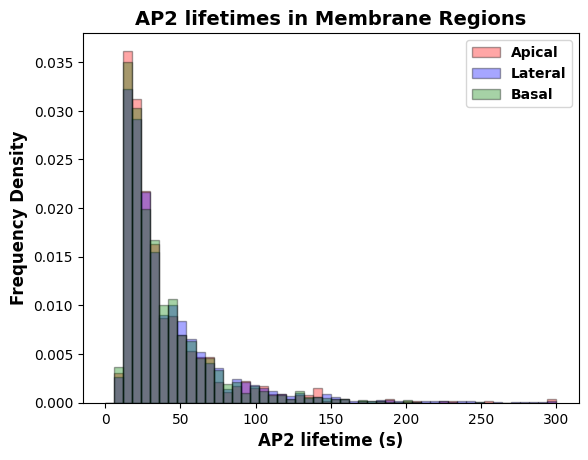

In [13]:
tracks_channel_subset_treatment = trackFilter('All', True, filtered_tracks_treatment)
lumenoid2_frame_ms = 2100
createHistogramAP2Lifetimes(tracks_channel_subset_treatment,lumenoid2_frame_ms,False)

<module 'matplotlib.pyplot' from 'c:\\Users\\Kenny\\anaconda3\\envs\\cme_pipeline\\lib\\site-packages\\matplotlib\\pyplot.py'>

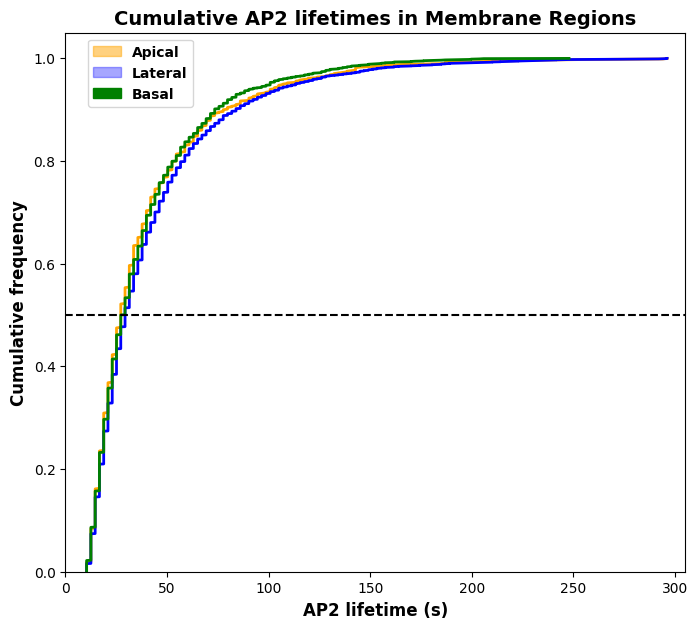

In [ ]:
# Cumulative plot of track lifetimes
plot_cumulative_lifetime(tracks_channel_subset_treatment, lumenoid2_frame_ms, conditions_list=[label1, label2, label3])


C:\Users\Kenny\AppData\Local\Temp\ipykernel_22472\2551807951.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([all_lifetimes_apical, all_lifetimes_lateral, all_lifetimes_basal],labels=[label1, label2, label3])


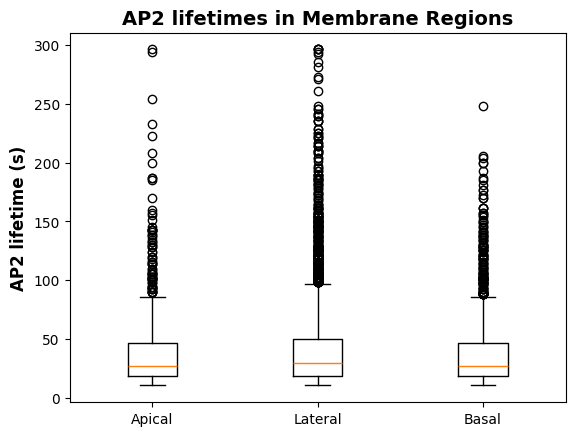

In [15]:
createBoxWhiskerPlot(tracks_channel_subset_treatment,False,lumenoid2_frame_ms)

## Lumenoid 1 Plots

In [16]:
compare_lumenoid_input_file_directory = 'lumenoid_1cropped_analysis/'
compare_lumenoid_df = pd.read_pickle(os.path.join(base_dir, compare_lumenoid_input_file_directory, 'datasets', 'region_filtered_tracks_final.pkl'))
lumenoid1_frame_ms = 2200


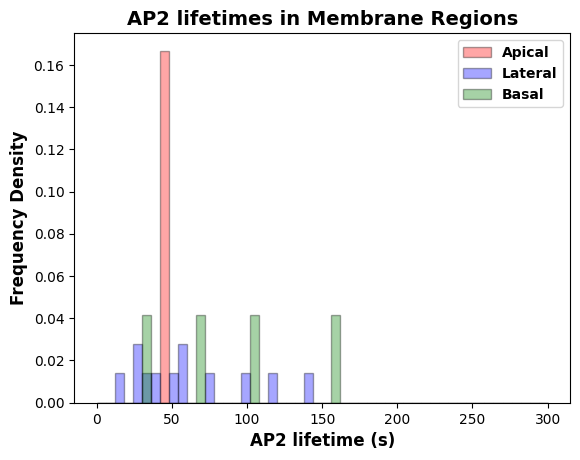

In [17]:
tracks_channel_subset_compare = trackFilter('All', False, compare_lumenoid_df)
createHistogramAP2Lifetimes(tracks_channel_subset_compare,lumenoid1_frame_ms,False)

C:\Users\Kenny\AppData\Local\Temp\ipykernel_22472\2551807951.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_lifetimes, labels=['Lumenoid 2'])


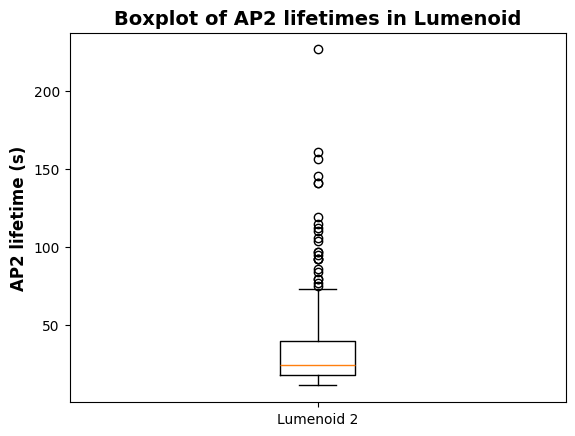

In [23]:
createBoxWhiskerPlot(tracks_channel_subset_compare,True,lumenoid1_frame_ms)

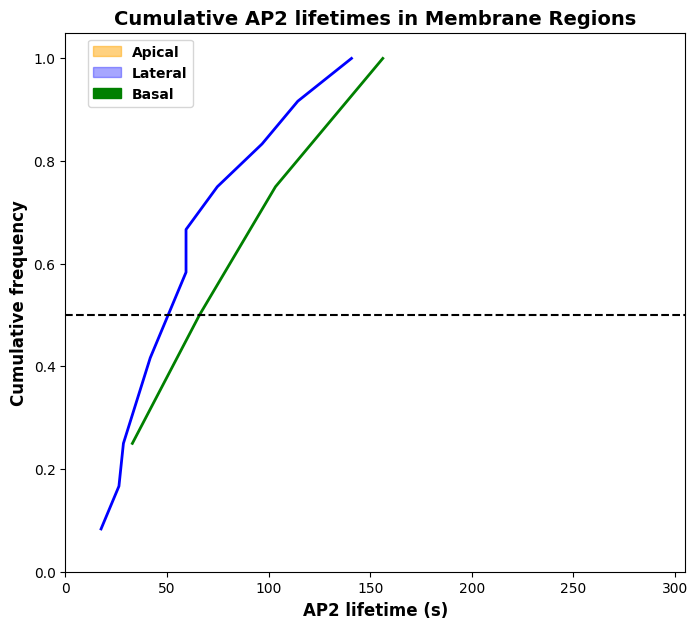

In [284]:
tracks_apical = tracks_channel_subset_compare[tracks_channel_subset_compare['membrane_region'] == 'Apical']
tracks_lateral = tracks_channel_subset_compare[tracks_channel_subset_compare['membrane_region'] == 'Lateral']
tracks_basal = tracks_channel_subset_compare[tracks_channel_subset_compare['membrane_region'] == 'Basal']
all_lifetimes_apical = tracks_apical['track_length']*lumenoid1_frame_ms/1000
all_lifetimes_lateral = tracks_lateral['track_length']*lumenoid1_frame_ms/1000
all_lifetimes_basal = tracks_basal['track_length']*lumenoid1_frame_ms/1000

all_lifetimes_apical_df = pd.DataFrame(all_lifetimes_apical)
all_lifetimes_lateral_df = pd.DataFrame(all_lifetimes_lateral)
all_lifetimes_basal_df = pd.DataFrame(all_lifetimes_basal)

# plt = plot_cumulative_lifetime(all_lifetimes_control_df, all_lifetimes_treatment_df, [label1, label2], title)
plt = plot_cumulative_lifetime(all_lifetimes_apical_df, all_lifetimes_lateral_df, all_lifetimes_basal_df, [label1, label2, label3])
# if plot_all_channels == True:
#     plt.text(0.5, 0.8, f'Plotting all channels: {plot_all_channels}', transform=plt.gca().transAxes, fontsize=12, weight='bold')
# if plot_all_channels == False:
#     plt.text(0.5, 0.8, f'Plotting channels: {channels_to_plot}', transform=plt.gca().transAxes, fontsize=12, weight='bold')
# plt.text(0.5, 0.75, f'Plotting region: {region_to_plot}', transform=plt.gca().transAxes, fontsize=12, weight='bold')

plt.show()

## Lumenoid 1 and Lumenoid 2 Comparasion Plots

C:\Users\Kenny\AppData\Local\Temp\ipykernel_22472\4060548734.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lumenoid1_all_lifetimes,lumenoid2_all_lifetimes], labels=[lumenoid1_name, lumenoid2_name])


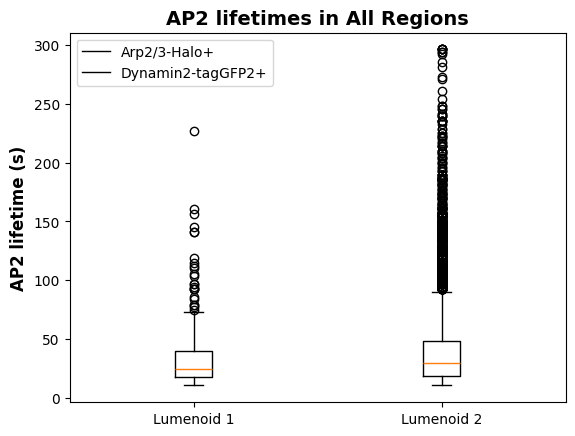

In [22]:
channels_to_plot = [True,True]
tracks_channel_subset_compare = trackFilter('All', True, compare_lumenoid_df, channels_to_plot)
boxplot_data_lumenoid2 = trackFilter('All', True, filtered_tracks_treatment,channels_to_plot)
compareLumenoidsBoxPlot(tracks_channel_subset_compare, boxplot_data_lumenoid2, 'All', 'Lumenoid 1', 'Lumenoid 2', lumenoid1_frame_ms, lumenoid2_frame_ms, channels_to_plot)
